# 03 — Consistencia país × año (SCRUM-11)

Matriz de cobertura y validación de integridad antes de Sprint 2.

**Jira:** SCRUM-11 / SCRUM-28

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from gympulse.config import CONSISTENCY_MATRIX, CONSISTENCY_SUMMARY, DEFAULT_CSV, EXPECTED_YEARS
from gympulse.consistency import build_consistency_report, save_consistency_report

matrix, summary = build_consistency_report()
save_consistency_report()

c = summary["consistency"]
print(f"Estado: {c['integrity_status']}")
print(f"Cobertura: {c['coverage_percent']}% | Huecos: {c['missing_cells']} | Duplicados: {c['duplicate_cells']}")

Estado: PASS
Cobertura: 100.0% | Huecos: 0 | Duplicados: 0


## Heatmap de cobertura (muestra: primeros 30 países)

Verde = 1 registro · Rojo = hueco o duplicado

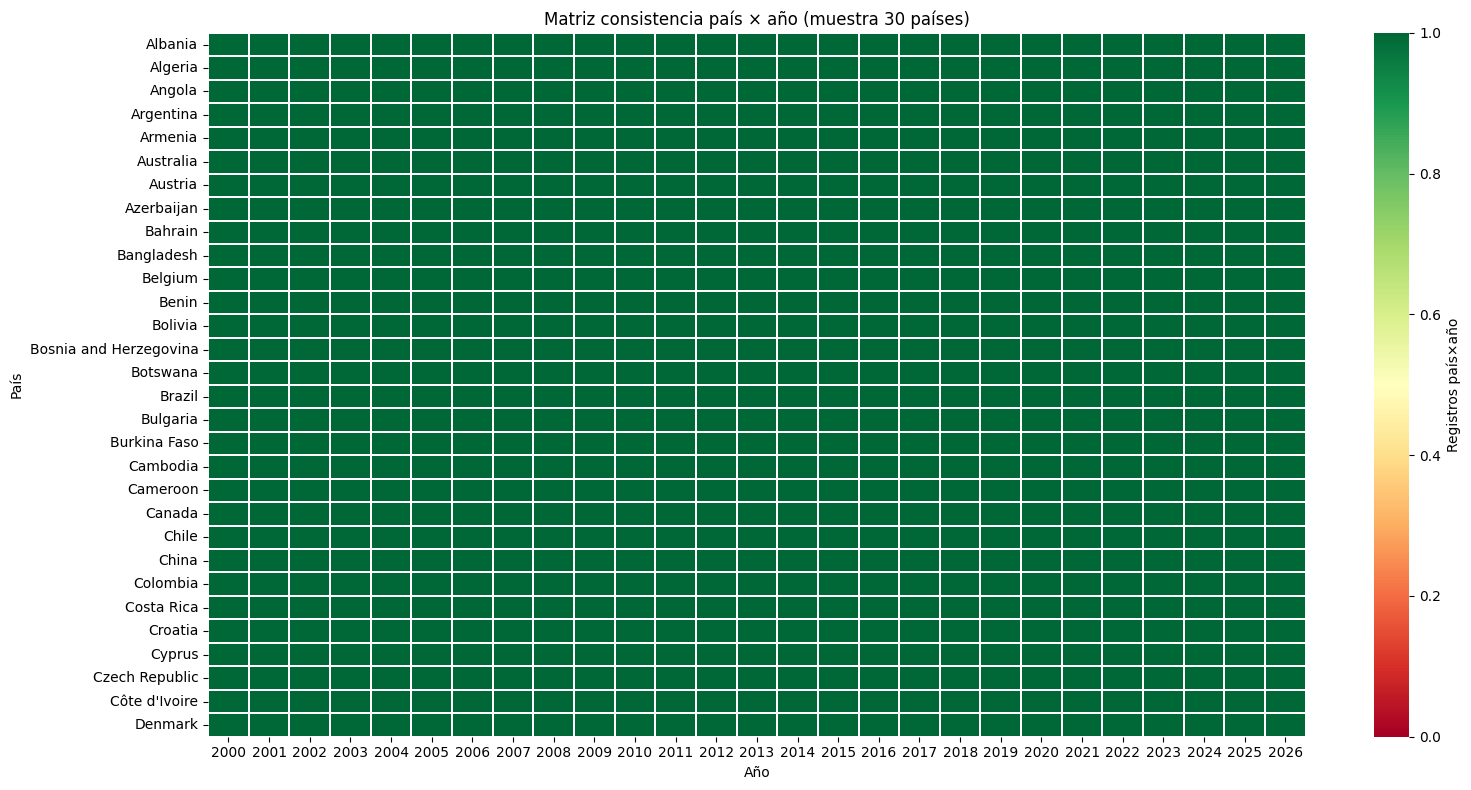

In [2]:
sample = matrix.head(30)
plt.figure(figsize=(16, 8))
sns.heatmap(
    sample,
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Registros país×año"},
    linewidths=0.1,
)
plt.title("Matriz consistencia país × año (muestra 30 países)")
plt.xlabel("Año")
plt.ylabel("País")
plt.tight_layout()
plt.show()

## Resumen ejecutivo para PO

In [3]:
po = pd.DataFrame([
    {"métrica": "Países", "valor": summary["source"]["unique_countries"]},
    {"métrica": "Registros", "valor": summary["source"]["total_records"]},
    {"métrica": "Celdas esperadas", "valor": c["expected_cells_country_year"]},
    {"métrica": "Cobertura %", "valor": c["coverage_percent"]},
    {"métrica": "Integridad", "valor": c["integrity_status"]},
])
po

,métrica,valor
0,Países,132
1,Registros,3564
2,Celdas esperadas,3564
3,Cobertura %,100.0
4,Integridad,PASS


## Archivos generados

- `reports/matriz_consistencia_scrum11.csv`
- `reports/reporte_consistencia_scrum11.json`